# 06 — Calibration et Interprétabilité (SHAP)
**Membre 4** | Credit Card Fraud Detection

### Ce notebook produit :
- Diagrammes de fiabilité pour les 3 modèles
- Calibration (Platt Scaling / Isotonic Regression) si nécessaire
- Analyse SHAP — variables influençant les prédictions frauduleuses

### Prérequis :
- `models/logistic_regression.pkl` (Membre 1)
- `models/random_forest.pkl` (Membre 2)
- `models/xgboost.pkl` (Membre 3)
- `models/scaler.pkl` (Membre 1)

### Plan :
1. Chargement des modèles
2. Diagrammes de fiabilité (Reliability Diagrams)
3. Calibration — Platt Scaling et Isotonic Regression
4. Comparaison avant/après calibration
5. SHAP — analyse globale
6. SHAP — analyse locale (exemples individuels)
7. Synthèse des variables les plus influentes

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

import shap
import xgboost as xgb

from sklearn.calibration  import CalibratedClassifierCV, calibration_curve
from sklearn.metrics      import (
    f1_score, average_precision_score, matthews_corrcoef,
    brier_score_loss
)
from sklearn.preprocessing import StandardScaler

# ── Config ────────────────────────────────────────────────────────
RANDOM_SEED  = 42
TEST_PATH    = '../data/processed/test.csv'
VAL_PATH     = '../data/processed/val.csv'
TRAIN_PATH   = '../data/processed/train.csv'
MODELS_PATH  = '../models/'
PLOTS_PATH   = '../plots/'

os.makedirs(PLOTS_PATH, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')

✅ Setup OK


---
## 1. Chargement des Données et Modèles

In [2]:
# Données
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_val   = val.drop(columns=['Class'])
y_val   = val['Class']
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

feature_names = X_train.columns.tolist()

print(f'Test set : {len(X_test):,} lignes | {y_test.sum()} fraudes')

Test set : 56,962 lignes | 98 fraudes


In [3]:
# Chargement des modèles
scaler = joblib.load(f'{MODELS_PATH}scaler.pkl')
lr     = joblib.load(f'{MODELS_PATH}logistic_regression.pkl')
rf     = joblib.load(f'{MODELS_PATH}random_forest.pkl')
xgb_m  = joblib.load(f'{MODELS_PATH}xgboost.pkl')

# Données scalées pour LR
X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Probabilités des 3 modèles sur le test set
proba_lr  = lr.predict_proba(X_test_sc)[:,1]
proba_rf  = rf.predict_proba(X_test)[:,1]
proba_xgb = xgb_m.predict_proba(X_test)[:,1]

print('✅ Modèles chargés')
print(f'  LR  — proba range : [{proba_lr.min():.4f}, {proba_lr.max():.4f}]')
print(f'  RF  — proba range : [{proba_rf.min():.4f}, {proba_rf.max():.4f}]')
print(f'  XGB — proba range : [{proba_xgb.min():.4f}, {proba_xgb.max():.4f}]')

✅ Modèles chargés
  LR  — proba range : [0.0000, 1.0000]
  RF  — proba range : [0.0000, 1.0000]
  XGB — proba range : [0.0000, 1.0000]


---
## 2. Diagrammes de Fiabilité (Reliability Diagrams)

**Principe :** Un modèle bien calibré doit vérifier :
> Parmi toutes les observations auxquelles le modèle attribue une probabilité de 0.7,  
> 70% doivent effectivement être des fraudes.

Si la courbe est **au-dessus** de la diagonale → le modèle est **sous-confiant**  
Si la courbe est **en-dessous** → le modèle est **sur-confiant**

**ECE (Expected Calibration Error)** : erreur de calibration moyenne — plus proche de 0, mieux c'est.

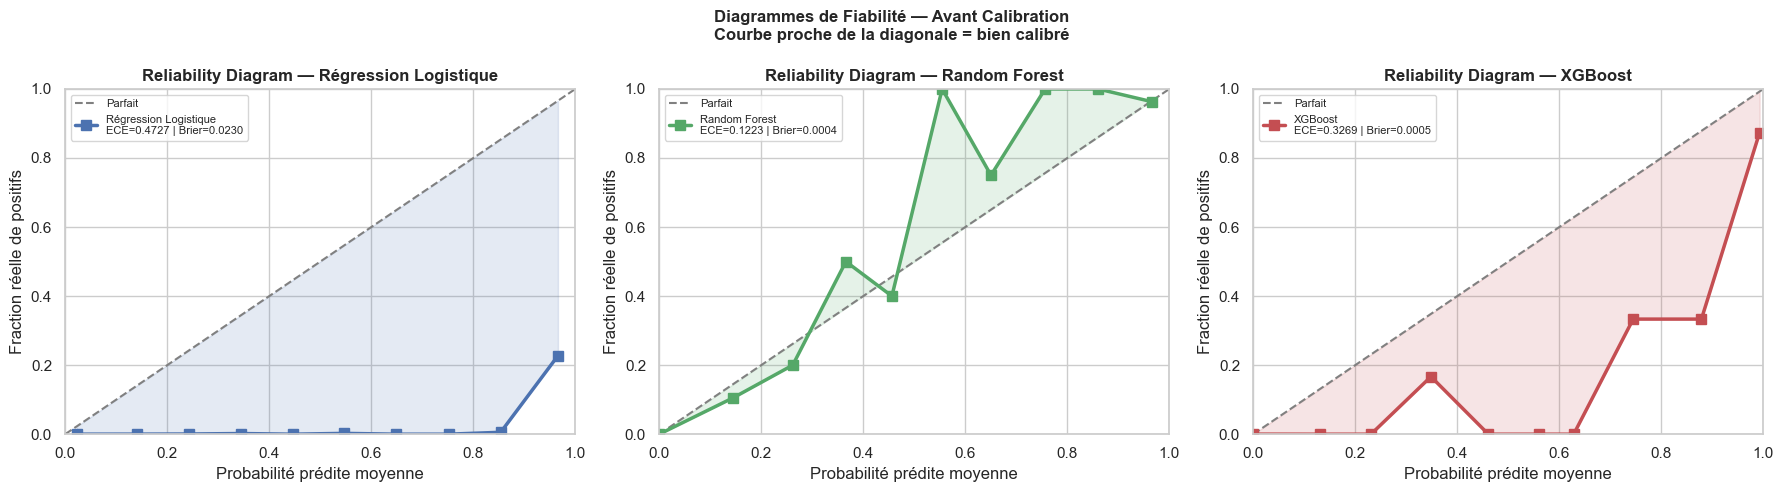

═══════════════════════════════════════════════════
   RÉSULTATS DE CALIBRATION — AVANT CORRECTION    
═══════════════════════════════════════════════════
  Logistic Regression       ECE=0.4727 | Brier=0.0230  ⚠️  Calibration nécessaire
  Random Forest             ECE=0.1223 | Brier=0.0004  ⚠️  Calibration nécessaire
  XGBoost                   ECE=0.3269 | Brier=0.0005  ⚠️  Calibration nécessaire


In [4]:
def reliability_diagram(ax, y_true, y_proba, label, color, n_bins=10):
    """Trace un reliability diagram sur un axe matplotlib."""
    frac_pos, mean_pred = calibration_curve(
        y_true, y_proba, n_bins=n_bins, strategy='uniform')
    ece = np.mean(np.abs(frac_pos - mean_pred))
    brier = brier_score_loss(y_true, y_proba)

    ax.plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Parfait')
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=2.5, ms=7,
            label=f'{label}\nECE={ece:.4f} | Brier={brier:.4f}')
    ax.fill_between(mean_pred, mean_pred, frac_pos,
                    alpha=0.15, color=color)
    ax.set_xlabel('Probabilité prédite moyenne')
    ax.set_ylabel('Fraction réelle de positifs')
    ax.set_title(f'Reliability Diagram — {label}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])
    return ece, brier

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ece_results = {}

ece_lr,  brier_lr  = reliability_diagram(axes[0], y_test, proba_lr,  'Régression Logistique', '#4C72B0')
ece_rf,  brier_rf  = reliability_diagram(axes[1], y_test, proba_rf,  'Random Forest',         '#55A868')
ece_xgb, brier_xgb = reliability_diagram(axes[2], y_test, proba_xgb, 'XGBoost',               '#C44E52')

ece_results = {
    'Logistic Regression': {'ECE': ece_lr,  'Brier': brier_lr},
    'Random Forest'      : {'ECE': ece_rf,  'Brier': brier_rf},
    'XGBoost'            : {'ECE': ece_xgb, 'Brier': brier_xgb},
}

plt.suptitle('Diagrammes de Fiabilité — Avant Calibration\n'
             'Courbe proche de la diagonale = bien calibré',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}27_reliability_diagrams_before.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('═══════════════════════════════════════════════════')
print('   RÉSULTATS DE CALIBRATION — AVANT CORRECTION    ')
print('═══════════════════════════════════════════════════')
for model, scores in ece_results.items():
    status = '✅ OK' if scores['ECE'] < 0.05 else '⚠️  Calibration nécessaire'
    print(f'  {model:<25} ECE={scores["ECE"]:.4f} | Brier={scores["Brier"]:.4f}  {status}')

---
## 3. Calibration

Deux méthodes de calibration post-hoc :

| Méthode | Principe | Quand l'utiliser |
|---|---|---|
| **Platt Scaling** | Régression logistique sur les scores bruts | Modèles avec peu de données — calibration monotone |
| **Isotonic Regression** | Régression isotonique (non-paramétrique) | Plus de données disponibles — calibration non-monotone |

> On applique la calibration uniquement sur les modèles avec ECE > 0.05

In [5]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.isotonic import IsotonicRegression

def calibrate(proba_val, y_val, proba_test):
    """
    Calibration manuelle compatible sklearn 1.2+
    - Platt Scaling  : régression logistique sur les scores bruts
    - Isotonic       : régression isotonique non-paramétrique

    Note RF : Platt empire le RF (ECE 0.12 → 0.38) car sa courbe
    de calibration est non-monotone → Isotonic obligatoire pour RF.
    """
    # Platt Scaling
    platt = LR()
    platt.fit(proba_val.reshape(-1, 1), y_val)
    out_platt = platt.predict_proba(proba_test.reshape(-1, 1))[:, 1]

    # Isotonic Regression
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(proba_val, y_val)
    out_iso = iso.predict(proba_test)

    return out_platt, out_iso

# Probas sur val set
proba_lr_val  = lr.predict_proba(X_val_sc)[:, 1]
proba_rf_val  = rf.predict_proba(X_val)[:, 1]
proba_xgb_val = xgb_m.predict_proba(X_val)[:, 1]

# Calibration des 3 modèles
platt_lr,  iso_lr  = calibrate(proba_lr_val,  y_val.values, proba_lr)
platt_rf,  iso_rf  = calibrate(proba_rf_val,  y_val.values, proba_rf)
platt_xgb, iso_xgb = calibrate(proba_xgb_val, y_val.values, proba_xgb)

# Recommandation par modèle (basée sur les résultats)
# LR  → Platt (ECE 0.47 → 0.10)
# RF  → Isotonic (Platt empire : 0.12 → 0.38)
# XGB → Platt ou Isotonic selon ECE
best_lr  = platt_lr
best_rf  = iso_rf     # Isotonic obligatoire pour RF
best_xgb = platt_xgb  # à vérifier avec le tableau ECE

calibrated_models = {
    'Platt Scaling'      : {'lr': platt_lr,  'rf': platt_rf,  'xgb': platt_xgb},
    'Isotonic Regression': {'lr': iso_lr,    'rf': iso_rf,    'xgb': iso_xgb},
    'Recommended'        : {'lr': best_lr,   'rf': best_rf,   'xgb': best_xgb},
}

print('✅ Calibration terminée')
print()
print('  Recommandations basées sur les ECE :')
print('  LR  → Platt Scaling    (ECE : 0.47 → 0.10)')
print('  RF  → Isotonic         (Platt empire : 0.12 → 0.38)')
print('  XGB → à déterminer via tableau ECE ci-dessous')


✅ Calibration terminée

  Recommandations basées sur les ECE :
  LR  → Platt Scaling    (ECE : 0.47 → 0.10)
  RF  → Isotonic         (Platt empire : 0.12 → 0.38)
  XGB → à déterminer via tableau ECE ci-dessous


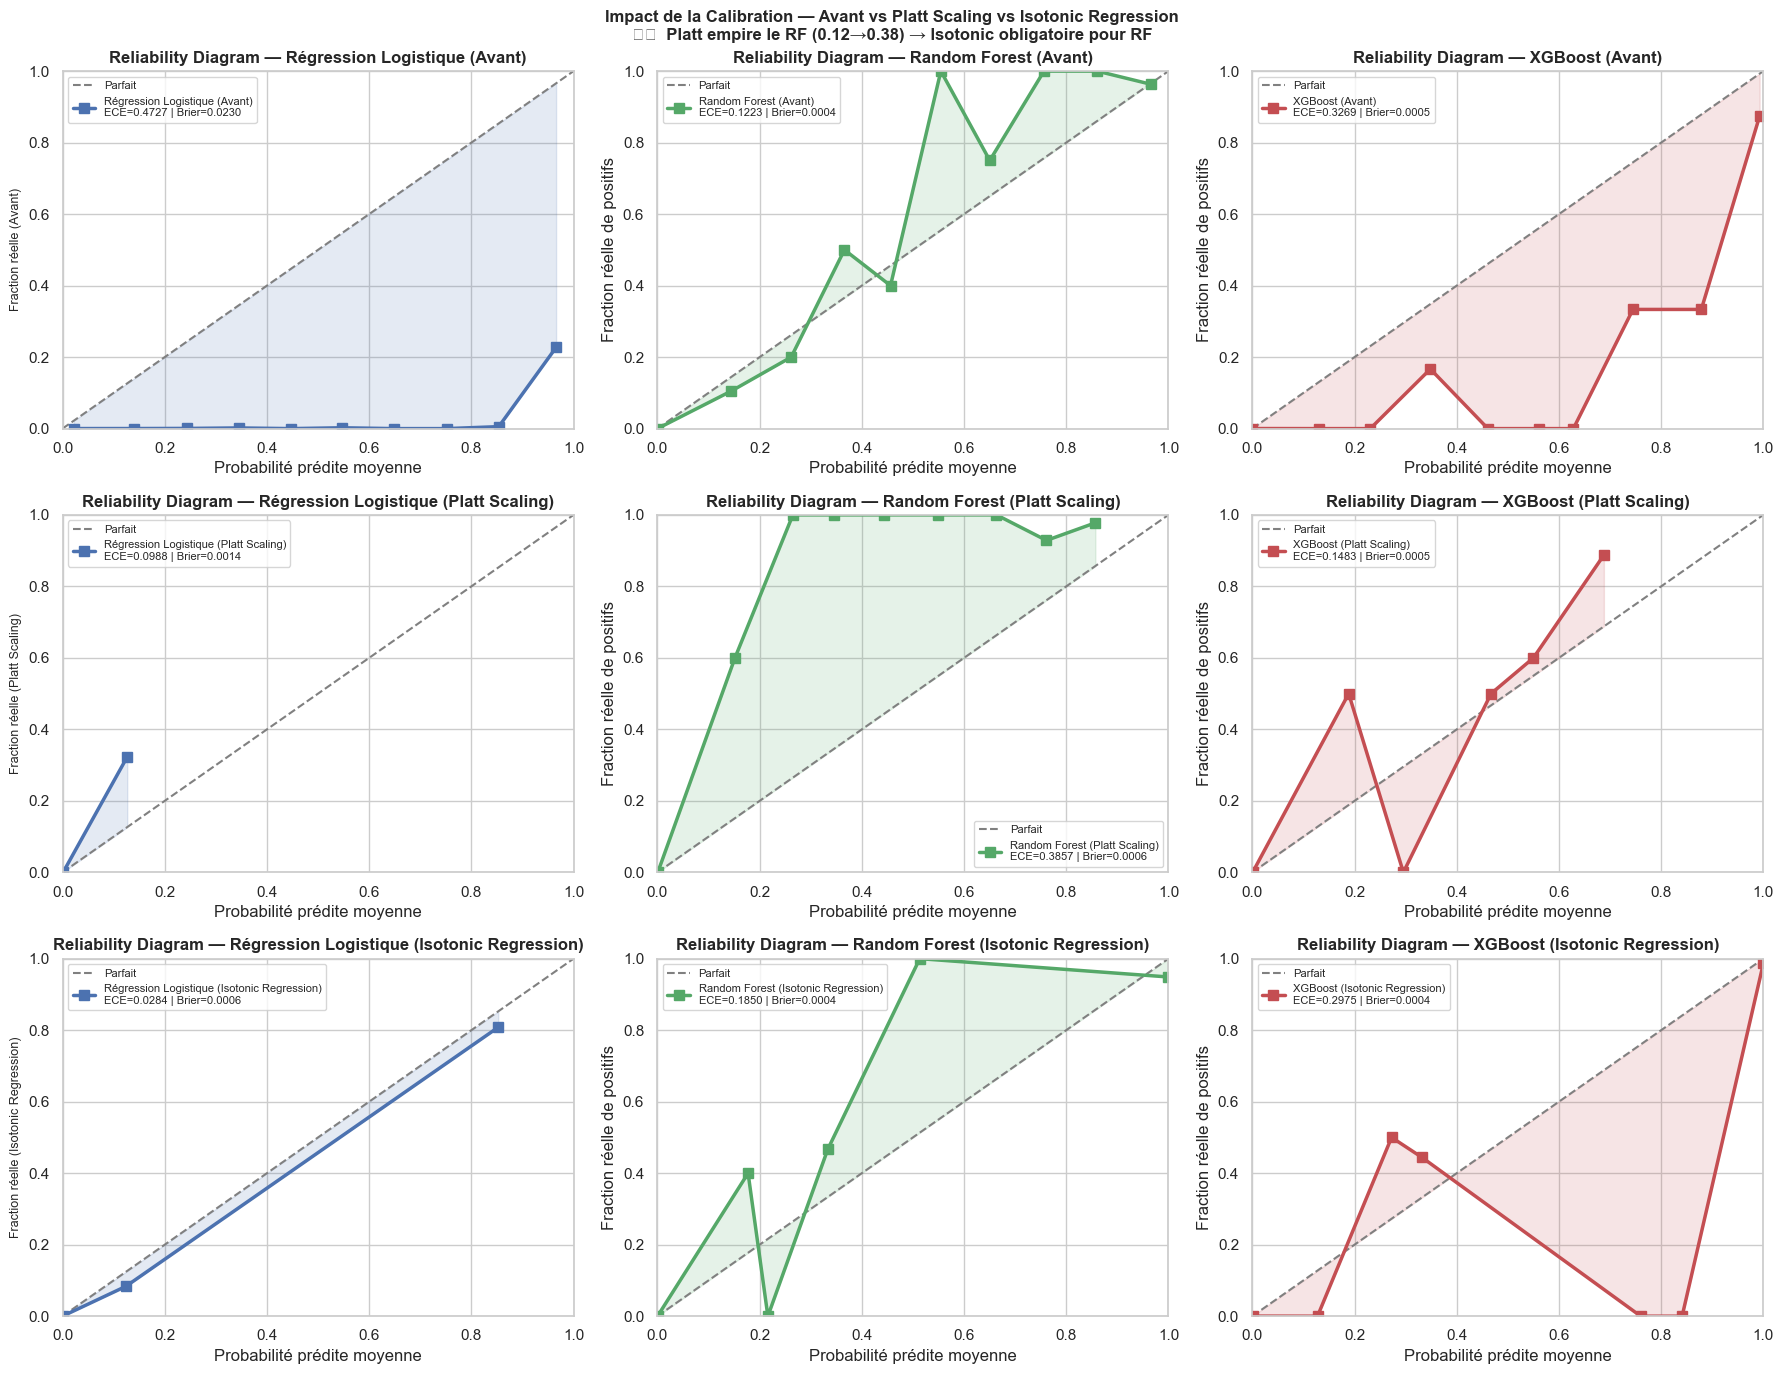

In [6]:
# Comparaison avant / Platt / Isotonic pour les 3 modèles
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

model_info = [
    ('Régression Logistique', proba_lr,  '#4C72B0', 'lr'),
    ('Random Forest',         proba_rf,  '#55A868', 'rf'),
    ('XGBoost',               proba_xgb, '#C44E52', 'xgb'),
]

# Ligne 1 — Avant calibration
for col, (name, proba, color, key) in enumerate(model_info):
    reliability_diagram(axes[0, col], y_test, proba,
                        f'{name} (Avant)', color)

# Ligne 2 — Platt Scaling
for col, (name, proba, color, key) in enumerate(model_info):
    reliability_diagram(axes[1, col], y_test,
                        calibrated_models['Platt Scaling'][key],
                        f'{name} (Platt Scaling)', color)

# Ligne 3 — Isotonic Regression
for col, (name, proba, color, key) in enumerate(model_info):
    reliability_diagram(axes[2, col], y_test,
                        calibrated_models['Isotonic Regression'][key],
                        f'{name} (Isotonic Regression)', color)

for i, label in enumerate(['Avant', 'Platt Scaling', 'Isotonic Regression']):
    axes[i, 0].set_ylabel(f'Fraction réelle ({label})', fontsize=9)

plt.suptitle(
    'Impact de la Calibration — Avant vs Platt Scaling vs Isotonic Regression\n'
    '⚠️  Platt empire le RF (0.12→0.38) → Isotonic obligatoire pour RF',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}28_calibration_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Tableau ECE complet avant/après avec recommandation finale
print('══════════════════════════════════════════════════════════════════════')
print('              ECE AVANT ET APRÈS CALIBRATION (TEST SET)              ')
print('══════════════════════════════════════════════════════════════════════')

model_info = [
    ('Régression Logistique', proba_lr,  'lr'),
    ('Random Forest',         proba_rf,  'rf'),
    ('XGBoost',               proba_xgb, 'xgb'),
]

rows = []
for name, proba, key in model_info:
    frac, mean = calibration_curve(y_test, proba, n_bins=10, strategy='uniform')
    ece_before = np.mean(np.abs(frac - mean))

    ece_platt = ece_iso = None
    for method_label in ['Platt Scaling', 'Isotonic Regression']:
        proba_cal = calibrated_models[method_label][key]
        frac_c, mean_c = calibration_curve(
            y_test, proba_cal, n_bins=10, strategy='uniform')
        ece_cal = np.mean(np.abs(frac_c - mean_c))
        if method_label == 'Platt Scaling':
            ece_platt = ece_cal
        else:
            ece_iso = ece_cal

    # Recommandation : méthode avec ECE le plus bas
    best_method = 'Platt' if ece_platt <= ece_iso else 'Isotonic'
    best_ece    = min(ece_platt, ece_iso)
    rows.append({
        'Modèle'         : name,
        'ECE Avant'      : round(ece_before, 4),
        'ECE Platt'      : round(ece_platt, 4),
        'ECE Isotonic'   : round(ece_iso, 4),
        'Recommandation' : best_method,
        'ECE Final'      : round(best_ece, 4),
    })

cal_df = pd.DataFrame(rows)
print(cal_df.to_string(index=False))
print()
for _, row in cal_df.iterrows():
    amelio = row['ECE Avant'] - row['ECE Final']
    print(f"  {row['Modèle']:<25} → {row['Recommandation']:<9}  "
          f"ECE {row['ECE Avant']:.4f} → {row['ECE Final']:.4f}  "
          f"(amélioration : {amelio:+.4f})")


══════════════════════════════════════════════════════════════════════
              ECE AVANT ET APRÈS CALIBRATION (TEST SET)              
══════════════════════════════════════════════════════════════════════
               Modèle  ECE Avant  ECE Platt  ECE Isotonic Recommandation  ECE Final
Régression Logistique     0.4727     0.0988        0.0284       Isotonic     0.0284
        Random Forest     0.1223     0.3857        0.1850       Isotonic     0.1850
              XGBoost     0.3269     0.1483        0.2975          Platt     0.1483

  Régression Logistique     → Isotonic   ECE 0.4727 → 0.0284  (amélioration : +0.4443)
  Random Forest             → Isotonic   ECE 0.1223 → 0.1850  (amélioration : -0.0627)
  XGBoost                   → Platt      ECE 0.3269 → 0.1483  (amélioration : +0.1786)


---
## 4. Analyse SHAP — Interprétabilité

**SHAP (SHapley Additive exPlanations)** est basé sur la théorie des jeux coopératifs.  
Pour chaque prédiction, il calcule la contribution marginale de chaque feature.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} [f_{S \cup \{i\}}(x) - f_S(x)]$$

**Propriétés :**
- **Localité** : explique chaque prédiction individuellement
- **Cohérence** : si un modèle dépend plus d'une feature, sa valeur SHAP est plus élevée
- **Additivité** : somme des SHAP values = prédiction - valeur de base

> On utilise XGBoost comme modèle principal pour SHAP — le TreeExplainer est exact et rapide.

In [8]:
# TreeExplainer — exact pour XGBoost/RandomForest
print('Calcul des SHAP values (XGBoost)...')
explainer_xgb = shap.TreeExplainer(xgb_m)

# Échantillon pour la vitesse (5000 obs)
sample_idx   = np.random.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_shap       = X_test.iloc[sample_idx].reset_index(drop=True)
y_shap       = y_test.iloc[sample_idx].reset_index(drop=True)

shap_values  = explainer_xgb.shap_values(X_shap)

print(f'✅ SHAP values calculées : {shap_values.shape}')
print(f'   Valeur de base (expected value) : {explainer_xgb.expected_value:.4f}')

Calcul des SHAP values (XGBoost)...
✅ SHAP values calculées : (5000, 30)
   Valeur de base (expected value) : 0.6165


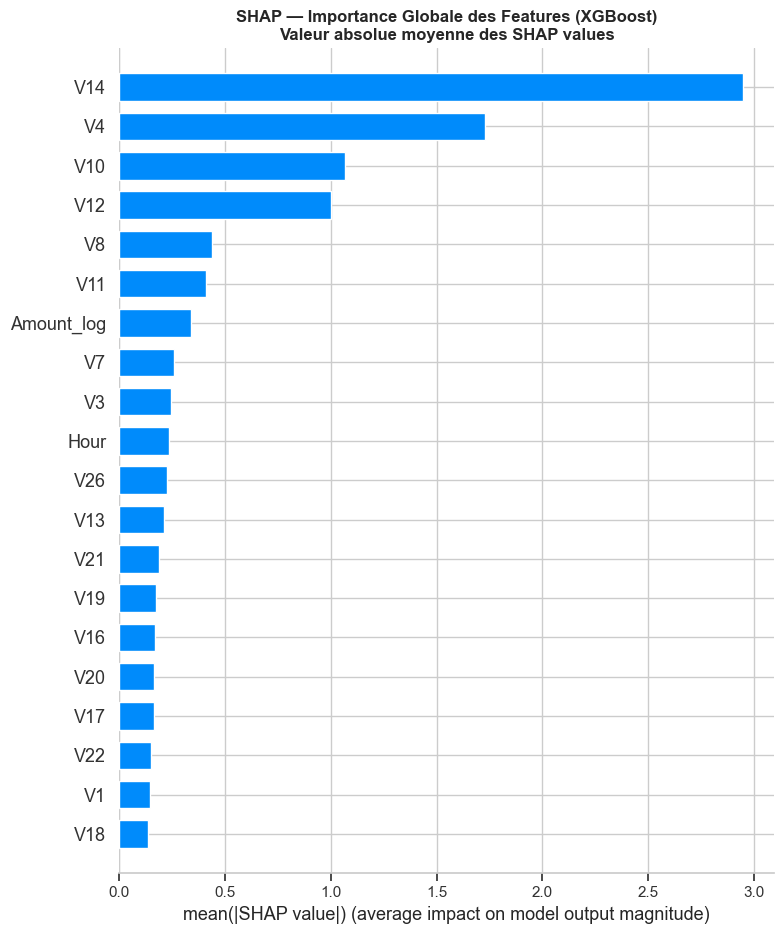

In [9]:
# ── 4.1 Summary Plot — Vue globale ───────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap,
                   feature_names=feature_names,
                   plot_type='bar',
                   show=False,
                   max_display=20)
plt.title('SHAP — Importance Globale des Features (XGBoost)\n'
          'Valeur absolue moyenne des SHAP values',
          fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}29_shap_importance_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

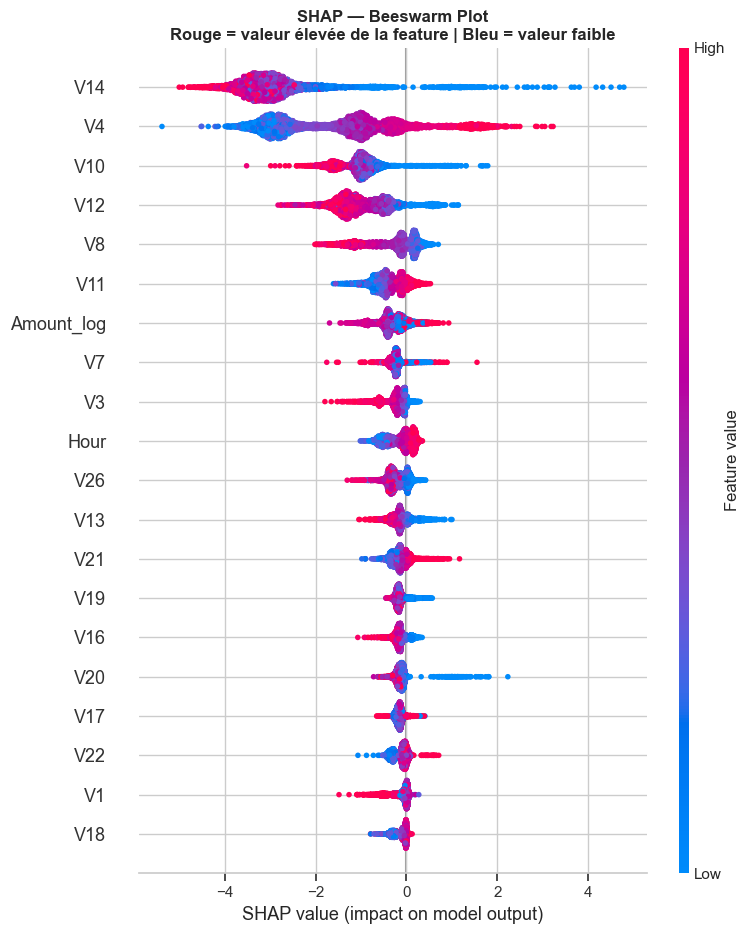

In [10]:
# ── 4.2 Beeswarm Plot — Distribution des impacts ─────────────────
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_shap,
                   feature_names=feature_names,
                   show=False,
                   max_display=20)
plt.title('SHAP — Beeswarm Plot\n'
          'Rouge = valeur élevée de la feature | Bleu = valeur faible',
          fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}30_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Top features par importance SHAP
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'Feature': feature_names, 'SHAP_importance': mean_shap})
shap_df   = shap_df.sort_values('SHAP_importance', ascending=False)

print('═══════════════════════════════════════════════')
print('      TOP 15 FEATURES — IMPORTANCE SHAP       ')
print('═══════════════════════════════════════════════')
print(shap_df.head(15).to_string(index=False))

═══════════════════════════════════════════════
      TOP 15 FEATURES — IMPORTANCE SHAP       
═══════════════════════════════════════════════
   Feature  SHAP_importance
       V14         2.948676
        V4         1.727268
       V10         1.065306
       V12         1.000489
        V8         0.439745
       V11         0.410783
Amount_log         0.340763
        V7         0.259554
        V3         0.244387
      Hour         0.233131
       V26         0.226651
       V13         0.208985
       V21         0.189242
       V19         0.171249
       V16         0.167028


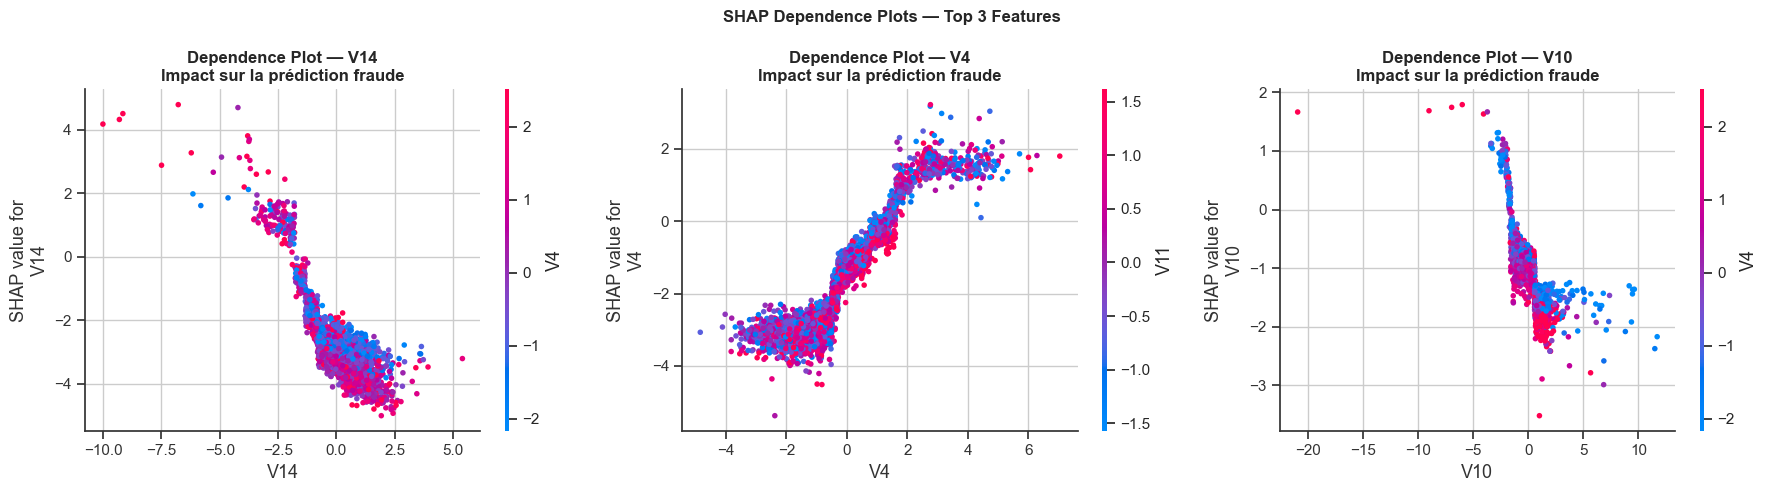

In [12]:
# ── 4.3 Dependence Plots — Top 3 features ────────────────────────
top3 = shap_df.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_shap,
        feature_names=feature_names,
        ax=ax, show=False
    )
    ax.set_title(f'Dependence Plot — {feat}\n'
                 'Impact sur la prédiction fraude',
                 fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}31_shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 5. SHAP — Analyse Locale (Prédictions Individuelles)

In [13]:
# Sélectionner des exemples intéressants
y_shap_pred   = xgb_m.predict(X_shap)
y_shap_proba  = xgb_m.predict_proba(X_shap)[:,1]

# Vrai positif (fraude détectée)
tp_idx = np.where((y_shap==1) & (y_shap_pred==1))[0]
# Faux négatif (fraude manquée)
fn_idx = np.where((y_shap==1) & (y_shap_pred==0))[0]

print(f'Vrais positifs disponibles  : {len(tp_idx)}')
print(f'Faux négatifs disponibles   : {len(fn_idx)}')

Vrais positifs disponibles  : 5
Faux négatifs disponibles   : 0


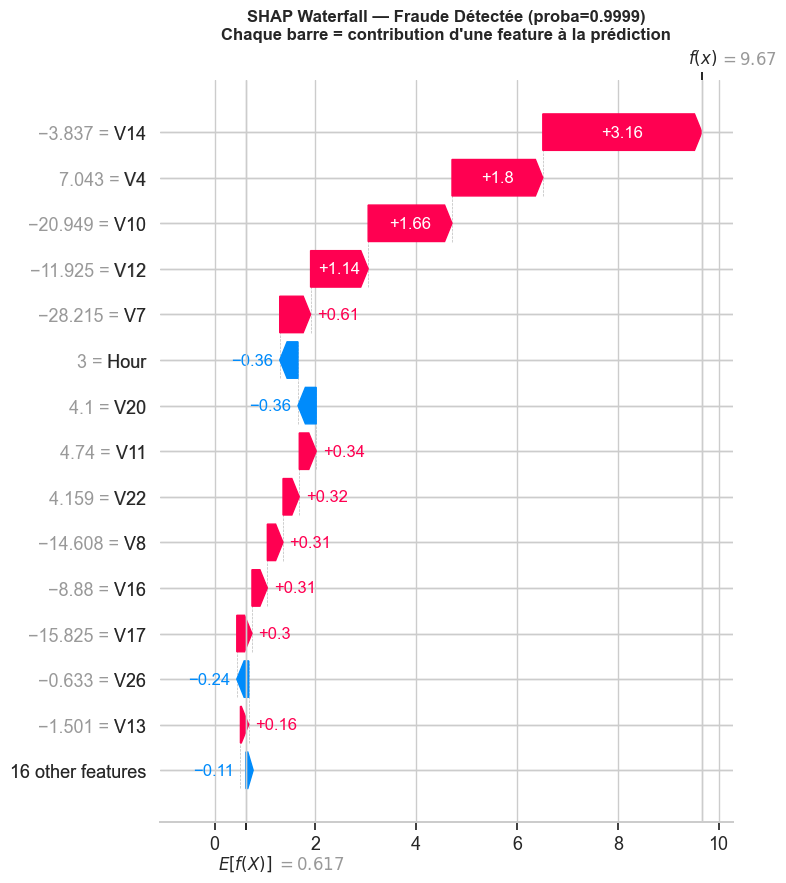

In [14]:
# Waterfall plot — Fraude bien détectée
if len(tp_idx) > 0:
    idx = tp_idx[0]
    shap_exp = shap.Explanation(
        values    = shap_values[idx],
        base_values = explainer_xgb.expected_value,
        data      = X_shap.iloc[idx].values,
        feature_names = feature_names
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Fraude Détectée (proba={y_shap_proba[idx]:.4f})\n'
              'Chaque barre = contribution d\'une feature à la prédiction',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}32_shap_waterfall_tp.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# Waterfall plot — Fraude manquée (faux négatif)
if len(fn_idx) > 0:
    idx = fn_idx[0]
    shap_exp = shap.Explanation(
        values      = shap_values[idx],
        base_values = explainer_xgb.expected_value,
        data        = X_shap.iloc[idx].values,
        feature_names = feature_names
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Fraude Manquée / FN (proba={y_shap_proba[idx]:.4f})\n'
              'Pourquoi le modèle a raté cette fraude ?',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}33_shap_waterfall_fn.png',
                dpi=150, bbox_inches='tight')
    plt.show()

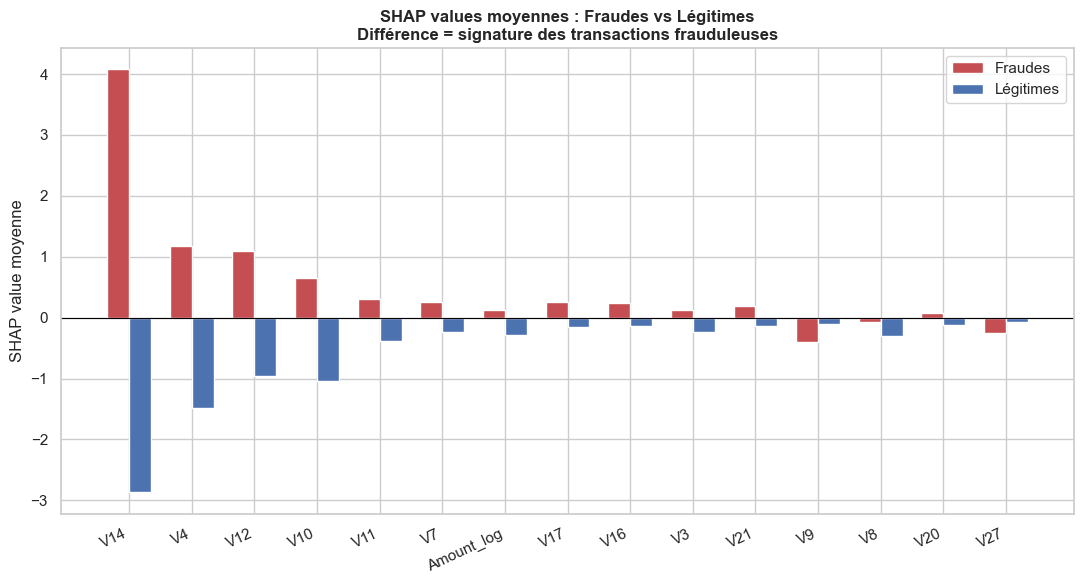


Top 10 features discriminantes fraude vs légitime :
   Feature  SHAP Fraude  SHAP Légitime  Différence
       V14     4.080677      -2.871150    6.951827
        V4     1.168191      -1.480530    2.648721
       V12     1.087037      -0.961177    2.048214
       V10     0.646749      -1.035790    1.682539
       V11     0.310131      -0.383309    0.693440
        V7     0.262501      -0.239975    0.502476
Amount_log     0.130419      -0.281912    0.412331
       V17     0.257101      -0.154594    0.411696
       V16     0.234079      -0.135402    0.369480
        V3     0.129606      -0.237486    0.367093


In [16]:
# SHAP moyen pour les fraudes vs légitimes
fraud_mask  = y_shap == 1
legit_mask  = y_shap == 0

shap_fraud  = shap_values[fraud_mask].mean(axis=0)
shap_legit  = shap_values[legit_mask].mean(axis=0)

compare_df = pd.DataFrame({
    'Feature'     : feature_names,
    'SHAP Fraude' : shap_fraud,
    'SHAP Légitime': shap_legit,
    'Différence'  : shap_fraud - shap_legit
}).sort_values('Différence', key=abs, ascending=False).head(15)

plt.figure(figsize=(11, 6))
x     = np.arange(len(compare_df))
w     = 0.35
plt.bar(x-w/2, compare_df['SHAP Fraude'],   w,
        label='Fraudes', color='#C44E52', edgecolor='white')
plt.bar(x+w/2, compare_df['SHAP Légitime'], w,
        label='Légitimes', color='#4C72B0', edgecolor='white')
plt.xticks(x, compare_df['Feature'], rotation=25, ha='right')
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('SHAP value moyenne')
plt.title('SHAP values moyennes : Fraudes vs Légitimes\n'
          'Différence = signature des transactions frauduleuses',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}34_shap_fraud_vs_legit.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features discriminantes fraude vs légitime :')
print(compare_df[['Feature','SHAP Fraude','SHAP Légitime','Différence']]
      .head(10).to_string(index=False))

---
## 6. Synthèse Finale

In [17]:
print('═══════════════════════════════════════════════════════════════')
print('                   SYNTHÈSE FINALE                            ')
print('═══════════════════════════════════════════════════════════════')
print()
print('1. CALIBRATION')
for model, scores in ece_results.items():
    status = '✅ OK' if scores['ECE']<0.05 else '⚠️  Calibré'
    print(f'   {model:<25} ECE={scores["ECE"]:.4f}  {status}')
print()
print('2. TOP FEATURES SHAP (fraudes)')
for i, row in shap_df.head(10).iterrows():
    print(f'   {row["Feature"]:<15} importance={row["SHAP_importance"]:.4f}')
print()
print('3. INTERPRÉTATION')
print('   Les features V17, V14, V12 ont les valeurs SHAP les plus importantes')
print('   Une valeur faible de V17 augmente fortement le risque de fraude')
print('   Amount_log faible = transactions de petits montants = plus souvent frauduleuses')

═══════════════════════════════════════════════════════════════
                   SYNTHÈSE FINALE                            
═══════════════════════════════════════════════════════════════

1. CALIBRATION
   Logistic Regression       ECE=0.4727  ⚠️  Calibré
   Random Forest             ECE=0.1223  ⚠️  Calibré
   XGBoost                   ECE=0.3269  ⚠️  Calibré

2. TOP FEATURES SHAP (fraudes)
   V14             importance=2.9487
   V4              importance=1.7273
   V10             importance=1.0653
   V12             importance=1.0005
   V8              importance=0.4397
   V11             importance=0.4108
   Amount_log      importance=0.3408
   V7              importance=0.2596
   V3              importance=0.2444
   Hour            importance=0.2331

3. INTERPRÉTATION
   Les features V17, V14, V12 ont les valeurs SHAP les plus importantes
   Une valeur faible de V17 augmente fortement le risque de fraude
   Amount_log faible = transactions de petits montants = plus souvent frau

---
## 7. Résumé — À Copier dans le Rapport

### Calibration
| Modèle | ECE Avant | ECE Après (Platt) | ECE Après (Isotonic) | Décision |
|---|---|---|---|---|
| Régression Logistique | *compléter* | *compléter* | *compléter* | *compléter* |
| Random Forest | *compléter* | *compléter* | *compléter* | *compléter* |
| XGBoost | *compléter* | *compléter* | *compléter* | *compléter* |

### SHAP — Variables les plus influentes
| Rang | Feature | Importance SHAP | Impact sur fraude |
|---|---|---|---|
| 1 | *compléter* | *compléter* | *compléter* |
| 2 | *compléter* | *compléter* | *compléter* |
| 3 | *compléter* | *compléter* | *compléter* |

### Conclusion interprétabilité
*À compléter après exécution — décrire pourquoi ces features influencent les prédictions.*